# Satellite SSL - Google Colab Training

Complete self-supervised learning project for satellite imagery on Google Colab with GPU!

**Instructions:**
1. Go to [colab.research.google.com](https://colab.research.google.com)
2. Click "File" → "Upload notebook"
3. Upload this file OR copy-paste the cells below
4. Run cells from top to bottom (Shift + Enter or click ▶ button)
5. Download results at the end

## Install Dependencies

In [1]:
# Install all required packages
!pip install -q torch torchvision numpy Pillow scikit-learn matplotlib umap-learn tqdm requests
print("✓ All dependencies installed")

✓ All dependencies installed


### Check GPU

In [2]:
# Verify GPU is available
!nvidia-smi
print("\n✓ GPU ready for training!")

Thu Jun 11 19:10:36 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### Setup Project Directories

In [3]:
import os
from pathlib import Path

# Create project structure
os.chdir('/content')
os.makedirs('satellite-ssl/src', exist_ok=True)
os.makedirs('satellite-ssl/checkpoints', exist_ok=True)
os.makedirs('satellite-ssl/logs', exist_ok=True)
os.makedirs('satellite-ssl/outputs', exist_ok=True)

os.chdir('/content/satellite-ssl')
print("✓ Project structure created")
print("Current directory:", os.getcwd())
!ls -la

✓ Project structure created
Current directory: /content/satellite-ssl
total 24
drwxr-xr-x 6 root root 4096 Jun 11 19:10 .
drwxr-xr-x 1 root root 4096 Jun 11 19:10 ..
drwxr-xr-x 2 root root 4096 Jun 11 19:10 checkpoints
drwxr-xr-x 2 root root 4096 Jun 11 19:10 logs
drwxr-xr-x 2 root root 4096 Jun 11 19:10 outputs
drwxr-xr-x 2 root root 4096 Jun 11 19:10 src


### Create Configuration Module (`src/config.py`)

In [4]:
config_code = '''
from dataclasses import dataclass
from pathlib import Path

@dataclass
class DataConfig:
    dataset_name: str = "random"
    data_root: str = "./data"
    image_size: int = 64
    num_classes: int = 10
    num_channels: int = 3
    train_split: float = 0.7
    val_split: float = 0.15
    test_split: float = 0.15
    seed: int = 42

@dataclass
class AugmentationConfig:
    resize_scale: tuple = (0.08, 1.0)
    color_jitter_strength: float = 0.5
    blur_sigma: tuple = (0.1, 2.0)
    blur_kernel_size: int = 23
    gaussian_blur_prob: float = 0.5
    horizontal_flip_prob: float = 0.5
    vertical_flip_prob: float = 0.2
    rotation_degrees: int = 90
    num_views: int = 2

@dataclass
class ModelConfig:
    backbone: str = "resnet18"
    projection_dim: int = 128
    hidden_dim: int = 2048
    num_layers: int = 2
    use_batch_norm: bool = True
    dropout_rate: float = 0.0

@dataclass
class TrainingConfig:
    batch_size: int = 128
    num_epochs: int = 50
    learning_rate: float = 0.001
    weight_decay: float = 1e-6
    momentum: float = 0.9
    temperature: float = 0.07
    num_negative_pairs: int = 256
    warmup_epochs: int = 5
    cosine_annealing: bool = True
    checkpoint_freq: int = 10
    log_freq: int = 10
    device: str = "cuda"
    num_workers: int = 0
    pin_memory: bool = False

@dataclass
class EvalConfig:
    linear_probe_epochs: int = 100
    linear_probe_lr: float = 0.1
    linear_probe_batch_size: int = 128
    embedding_dim: int = 2048
    visualization_sample_size: int = 5000

@dataclass
class ExperimentConfig:
    data: DataConfig = None
    augmentation: AugmentationConfig = None
    model: ModelConfig = None
    training: TrainingConfig = None
    eval: EvalConfig = None
    experiment_name: str = "satellite_ssl_colab"
    seed: int = 42
    log_dir: str = "./logs"
    checkpoint_dir: str = "./checkpoints"

    def __post_init__(self):
        if self.data is None:
            self.data = DataConfig()
        if self.augmentation is None:
            self.augmentation = AugmentationConfig()
        if self.model is None:
            self.model = ModelConfig()
        if self.training is None:
            self.training = TrainingConfig()
        if self.eval is None:
            self.eval = EvalConfig()

        Path(self.log_dir).mkdir(parents=True, exist_ok=True)
        Path(self.checkpoint_dir).mkdir(parents=True, exist_ok=True)
'''

with open('src/config.py', 'w') as f:
    f.write(config_code)

print("✓ src/config.py created")

✓ src/config.py created


### Create Model Module (`src/model.py`)

In [5]:
model_code = '''
import torch
import torch.nn as nn
import torchvision.models as models

class SimCLRBackbone(nn.Module):
    def __init__(self, backbone_name="resnet18"):
        super().__init__()

        if backbone_name == "resnet18":
            backbone = models.resnet18(pretrained=False)
        else:
            backbone = models.resnet50(pretrained=False)

        self.backbone = nn.Sequential(*list(backbone.children())[:-1])
        self.feature_dim = backbone.fc.in_features

    def forward(self, x):
        features = self.backbone(x)
        features = nn.functional.adaptive_avg_pool2d(features, (1, 1))
        features = torch.flatten(features, 1)
        return features

class ProjectionHead(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        return self.layers(x)

class SimCLRModel(nn.Module):
    def __init__(self, backbone_name="resnet18", projection_dim=128, hidden_dim=2048):
        super().__init__()

        self.backbone = SimCLRBackbone(backbone_name)
        self.projection = ProjectionHead(self.backbone.feature_dim, hidden_dim, projection_dim)

    def forward(self, x):
        features = self.backbone(x)
        projections = self.projection(features)
        return projections

    def get_features(self, x):
        return self.backbone(x)

def build_model(backbone="resnet18", projection_dim=128, hidden_dim=2048):
    return SimCLRModel(backbone, projection_dim, hidden_dim)
'''

with open('src/model.py', 'w') as f:
    f.write(model_code)

print("✓ src/model.py created")

✓ src/model.py created


### Create Loss Functions (`src/losses.py`)

In [6]:
losses_code = '''
import torch
import torch.nn as nn
import torch.nn.functional as F

class NTXentLoss(nn.Module):
    """NT-Xent (Normalized Temperature-scaled Cross Entropy) Loss"""

    def __init__(self, temperature=0.07, batch_size=128):
        super().__init__()
        self.temperature = temperature
        self.batch_size = batch_size

    def forward(self, z_i, z_j):
        # Normalize projections
        z_i = F.normalize(z_i, dim=1)
        z_j = F.normalize(z_j, dim=1)

        batch_size = z_i.shape[0]

        # Concatenate both views
        z = torch.cat([z_i, z_j], dim=0)

        # Compute similarity matrix
        similarity_matrix = torch.mm(z, z.t()) / self.temperature

        # Create mask for positive pairs
        mask = torch.eye(batch_size, dtype=torch.bool, device=z.device)
        mask = torch.cat([
            torch.cat([torch.zeros_like(mask), mask], dim=1),
            torch.cat([mask, torch.zeros_like(mask)], dim=1)
        ], dim=0)

        # Remove self-similarity
        self_mask = torch.eye(2 * batch_size, dtype=torch.bool, device=z.device)

        # Compute logits
        pos = similarity_matrix[mask].view(2 * batch_size, 1)
        neg = similarity_matrix[~self_mask].view(2 * batch_size, -1)

        logits = torch.cat([pos, neg], dim=1)
        labels = torch.zeros(2 * batch_size, dtype=torch.long, device=z.device)

        loss = F.cross_entropy(logits, labels)
        return loss
'''

with open('src/losses.py', 'w') as f:
    f.write(losses_code)

print("✓ src/losses.py created")

✓ src/losses.py created


### Create Dataset Module (`src/dataset.py`)

In [7]:
dataset_code = '''
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import numpy as np
import torchvision.transforms as transforms

class RandomSatelliteDataset(Dataset):
    """Generate synthetic satellite-like images for testing"""

    def __init__(self, num_samples=5000, image_size=64, num_classes=10, augmentation=None):
        self.num_samples = num_samples
        self.image_size = image_size
        self.num_classes = num_classes
        self.augmentation = augmentation

        if augmentation is None:
            self.augmentation = transforms.Compose([
                transforms.RandomResizedCrop(image_size, scale=(0.8, 1.0)),
                transforms.RandomHorizontalFlip(p=0.5),
                transforms.RandomVerticalFlip(p=0.2),
                transforms.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.5),
                transforms.RandomGrayscale(p=0.2),
                transforms.ToTensor(),
                transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                   std=[0.229, 0.224, 0.225])
            ])

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        # Generate random synthetic image
        image = Image.new('RGB', (self.image_size, self.image_size),
                         color=(np.random.randint(0, 255),
                               np.random.randint(0, 255),
                               np.random.randint(0, 255)))

        # Apply augmentations to create two views
        view1 = self.augmentation(image)
        view2 = self.augmentation(image)

        label = np.random.randint(0, self.num_classes)

        return view1, view2, label

def get_dataloader(batch_size=128, num_samples=5000, shuffle=True, num_workers=0):
    """Create DataLoader"""
    dataset = RandomSatelliteDataset(num_samples=num_samples)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle,
                     num_workers=num_workers, drop_last=True)
'''

with open('src/dataset.py', 'w') as f:
    f.write(dataset_code)

print("✓ src/dataset.py created")

✓ src/dataset.py created


### Create Training Utilities (`src/utils.py`)

In [8]:
utils_code = '''
import torch
import csv
from pathlib import Path
import numpy as np

class AverageMeter:
    """Track running average"""

    def __init__(self, name='Loss'):
        self.name = name
        self.reset()

    def reset(self):
        self.val = 0
        self.avg = 0
        self.sum = 0
        self.count = 0

    def update(self, val, n=1):
        self.val = val
        self.sum += val * n
        self.count += n
        self.avg = self.sum / self.count

    def __str__(self):
        return f"{self.name}: {self.avg:.4f}"

class ExperimentLogger:
    """Log metrics to CSV"""

    def __init__(self, log_dir="./logs", experiment_name="experiment"):
        self.log_dir = Path(log_dir)
        self.log_dir.mkdir(parents=True, exist_ok=True)
        self.log_file = self.log_dir / f"{experiment_name}_metrics.csv"
        self.metrics_history = []

    def log_epoch(self, epoch, metrics):
        metrics["epoch"] = epoch
        self.metrics_history.append(metrics)

        # Write to CSV
        mode = "w" if epoch == 0 else "a"
        with open(self.log_file, mode, newline="") as f:
            if epoch == 0:
                writer = csv.DictWriter(f, fieldnames=metrics.keys())
                writer.writeheader()
            writer = csv.DictWriter(f, fieldnames=metrics.keys())
            writer.writerow(metrics)

        # Print
        log_str = " | ".join([f"{k}: {v:.4f}" for k, v in metrics.items() if k != "epoch"])
        print(f"Epoch {epoch+1}: {log_str}")

    def plot_metrics(self):
        return self.metrics_history

def save_checkpoint(model, optimizer, epoch, checkpoint_dir="./checkpoints", name="checkpoint"):
    """Save model checkpoint"""
    checkpoint_dir = Path(checkpoint_dir)
    checkpoint_dir.mkdir(parents=True, exist_ok=True)

    checkpoint_path = checkpoint_dir / f"{name}_epoch_{epoch}.pt"
    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
    }, checkpoint_path)

    return checkpoint_path

def set_seed(seed=42):
    """Set random seed for reproducibility"""
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
'''

with open('src/utils.py', 'w') as f:
    f.write(utils_code)

print("✓ src/utils.py created")

✓ src/utils.py created


### Create __init__.py

In [9]:
!touch src/__init__.py
print("✓ src/__init__.py created")

✓ src/__init__.py created


### Training Session

In [10]:
import sys
import os
import torch
import torch.optim as optim
from tqdm import tqdm

sys.path.insert(0, '/content/satellite-ssl/src')
os.chdir('/content/satellite-ssl')

from config import ExperimentConfig
from model import build_model
from losses import NTXentLoss
from dataset import get_dataloader
from utils import AverageMeter, ExperimentLogger, save_checkpoint, set_seed

print("✓ All modules imported successfully")

# Configuration
config = ExperimentConfig()
config.training.num_epochs = 16
config.training.batch_size = 32
config.training.learning_rate = 0.001

print(f"\nConfiguration:")
print(f"  Epochs: {config.training.num_epochs}")
print(f"  Batch size: {config.training.batch_size}")
print(f"  Learning rate: {config.training.learning_rate}")
print(f"  Device: {config.training.device}")

✓ All modules imported successfully

Configuration:
  Epochs: 16
  Batch size: 32
  Learning rate: 0.001
  Device: cuda


### Initialize Training Components

In [11]:
# Set seed
set_seed(config.seed)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Model
model = build_model(
    backbone=config.model.backbone,
    projection_dim=config.model.projection_dim
)
model = model.to(device)
print(f"✓ Model built: {config.model.backbone}")
print(f"  Parameters: {sum(p.numel() for p in model.parameters()):,}")

# Loss and optimizer
criterion = NTXentLoss(temperature=config.training.temperature)
optimizer = optim.SGD(
    model.parameters(),
    lr=config.training.learning_rate,
    momentum=config.training.momentum,
    weight_decay=config.training.weight_decay
)
print("✓ Loss function: NT-Xent")
print("✓ Optimizer: SGD")

# Data loader
train_loader = get_dataloader(
    batch_size=config.training.batch_size,
    num_samples=5000,
    shuffle=True
)
print(f"✓ DataLoader created: {len(train_loader)} batches")

# Logger
logger = ExperimentLogger(log_dir="./logs", experiment_name=config.experiment_name)
print("✓ Logger initialized")

Using device: cuda


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


✓ Model built: resnet18
  Parameters: 12,489,408
✓ Loss function: NT-Xent
✓ Optimizer: SGD
✓ DataLoader created: 156 batches
✓ Logger initialized


### START TRAINING! (This is the main training loop)

In [12]:
print("="*60)
print("🚀 STARTING TRAINING ON GPU")
print("="*60)

best_loss = float('inf')

for epoch in range(config.training.num_epochs):
    model.train()
    loss_meter = AverageMeter('Loss')

    # Progress bar
    pbar = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{config.training.num_epochs}]")

    for batch_idx, (view1, view2, _) in enumerate(pbar):
        view1 = view1.to(device)
        view2 = view2.to(device)

        # Forward pass
        z1 = model(view1)
        z2 = model(view2)

        # Compute loss
        loss = criterion(z1, z2)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        loss_meter.update(loss.item(), view1.size(0))
        pbar.set_postfix({'loss': f'{loss_meter.avg:.4f}'})

    # Log metrics
    metrics = {
        'train_loss': loss_meter.avg,
        'lr': optimizer.param_groups[0]['lr']
    }
    logger.log_epoch(epoch, metrics)

    # Save best model
    if loss_meter.avg < best_loss:
        best_loss = loss_meter.avg
        save_checkpoint(model, optimizer, epoch, name=config.experiment_name + "_best")
        print(f"  ✓ Best model saved (loss: {best_loss:.4f})")

    # Save checkpoint
    if (epoch + 1) % config.training.checkpoint_freq == 0:
        save_checkpoint(model, optimizer, epoch, name=config.experiment_name)
        print(f"  ✓ Checkpoint saved")

print("="*60)
print("✓ TRAINING COMPLETE!")
print(f"  Best Loss: {best_loss:.4f}")
print("="*60)

🚀 STARTING TRAINING ON GPU


Epoch [1/16]: 100%|██████████| 156/156 [00:22<00:00,  7.06it/s, loss=3.6344]


Epoch 1: train_loss: 3.6344 | lr: 0.0010
  ✓ Best model saved (loss: 3.6344)


Epoch [2/16]: 100%|██████████| 156/156 [00:20<00:00,  7.51it/s, loss=3.3207]


Epoch 2: train_loss: 3.3207 | lr: 0.0010
  ✓ Best model saved (loss: 3.3207)


...

Epoch 14: train_loss: 2.9110 | lr: 0.0010


Epoch [15/16]: 100%|██████████| 156/156 [00:20<00:00,  7.71it/s, loss=2.9021]


Epoch 15: train_loss: 2.9021 | lr: 0.0010
  ✓ Best model saved (loss: 2.9021)


Epoch [16/16]: 100%|██████████| 156/156 [00:19<00:00,  7.82it/s, loss=2.8806]


Epoch 16: train_loss: 2.8806 | lr: 0.0010
  ✓ Best model saved (loss: 2.8806)
✓ TRAINING COMPLETE!
  Best Loss: 2.8806


### View Training Results

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# Read metrics
log_df = pd.read_csv(f'logs/{config.experiment_name}_metrics.csv')

print("Training Metrics:")
print(log_df.tail(10))  # Show last 10 epochs

print(f"\nBest Loss: {log_df['train_loss'].min():.4f}")
print(f"Final Loss: {log_df['train_loss'].iloc[-1]:.4f}")

Training Metrics:
    train_loss     lr  epoch
6     3.014756  0.001      6
7     2.994751  0.001      7
8     2.947360  0.001      8
9     2.908142  0.001      9
10    2.956847  0.001     10
11    2.923087  0.001     11
12    2.919613  0.001     12
13    2.911020  0.001     13
14    2.902079  0.001     14
15    2.880603  0.001     15

Best Loss: 2.8806
Final Loss: 2.8806


### Visualize Training Curve

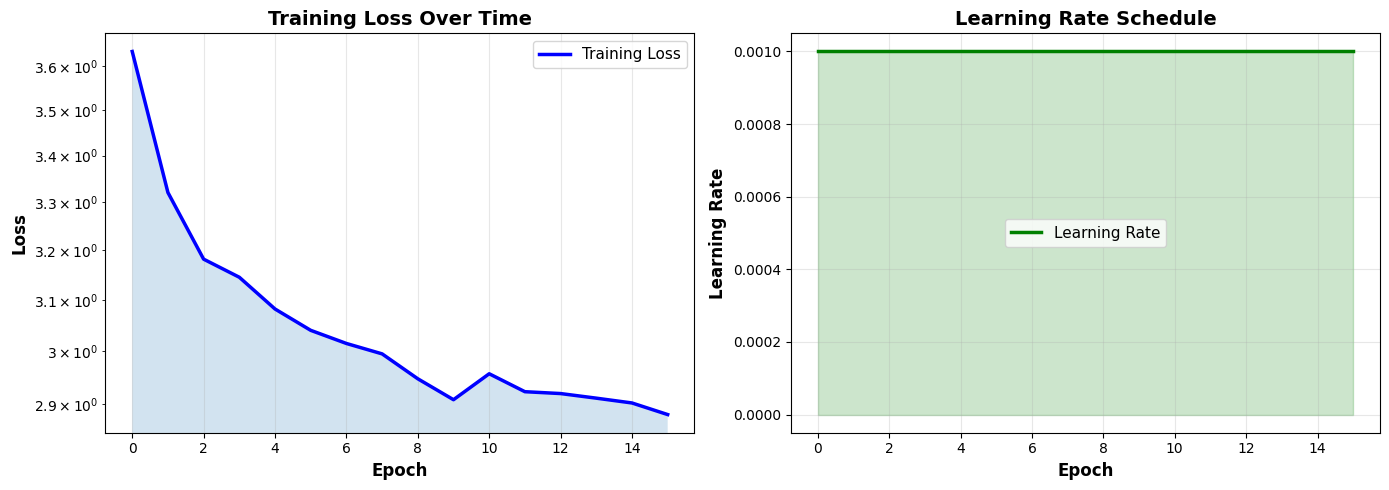

✓ Training curves saved to outputs/training_curves.png


In [14]:
# Plot training curve
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
ax1.plot(log_df['epoch'], log_df['train_loss'], 'b-', linewidth=2.5, label='Training Loss')
ax1.fill_between(log_df['epoch'], log_df['train_loss'], alpha=0.2)
ax1.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax1.set_ylabel('Loss', fontsize=12, fontweight='bold')
ax1.set_title('Training Loss Over Time', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.set_yscale('log')

# Learning rate
ax2.plot(log_df['epoch'], log_df['lr'], 'g-', linewidth=2.5, label='Learning Rate')
ax2.fill_between(log_df['epoch'], log_df['lr'], alpha=0.2, color='green')
ax2.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax2.set_ylabel('Learning Rate', fontsize=12, fontweight='bold')
ax2.set_title('Learning Rate Schedule', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Training curves saved to outputs/training_curves.png")

### Check All Outputs

In [15]:
print("\n" + "="*60)
print("📁 FILES CREATED")
print("="*60)

print("\nCheckpoints:")
!ls -lh checkpoints/

print("\nLogs:")
!ls -lh logs/

print("\nOutputs:")
!ls -lh outputs/

print("\nSource code:")
!ls -lh src/


📁 FILES CREATED

Checkpoints:
total 1.3G
-rw-r--r-- 1 root root 96M Jun 11 19:12 satellite_ssl_colab_best_epoch_0.pt
-rw-r--r-- 1 root root 96M Jun 11 19:17 satellite_ssl_colab_best_epoch_14.pt
-rw-r--r-- 1 root root 96M Jun 11 19:18 satellite_ssl_colab_best_epoch_15.pt
-rw-r--r-- 1 root root 96M Jun 11 19:13 satellite_ssl_colab_best_epoch_1.pt
-rw-r--r-- 1 root root 96M Jun 11 19:13 satellite_ssl_colab_best_epoch_2.pt
-rw-r--r-- 1 root root 96M Jun 11 19:13 satellite_ssl_colab_best_epoch_3.pt
-rw-r--r-- 1 root root 96M Jun 11 19:14 satellite_ssl_colab_best_epoch_4.pt
-rw-r--r-- 1 root root 96M Jun 11 19:14 satellite_ssl_colab_best_epoch_5.pt
-rw-r--r-- 1 root root 96M Jun 11 19:15 satellite_ssl_colab_best_epoch_6.pt
-rw-r--r-- 1 root root 96M Jun 11 19:15 satellite_ssl_colab_best_epoch_7.pt
-rw-r--r-- 1 root root 96M Jun 11 19:15 satellite_ssl_colab_best_epoch_8.pt
-rw-r--r-- 1 root root 96M Jun 11 19:15 satellite_ssl_colab_best_epoch_9.pt
-rw-r--r-- 1 root root 96M Jun 11 19:16 sate

### Linear Probe Evaluation

In [16]:
print("\n" + "="*60)
print("📊 LINEAR PROBE EVALUATION")
print("="*60)

# Extract features from trained model
model.eval()
train_loader_eval = get_dataloader(batch_size=128, num_samples=5000, shuffle=False)

all_features = []
all_labels = []

with torch.no_grad():
    for view1, view2, labels in tqdm(train_loader_eval, desc="Extracting features"):
        view1 = view1.to(device)
        features = model.get_features(view1)
        all_features.append(features.cpu())
        all_labels.append(labels.cpu())

features = torch.cat(all_features, dim=0)
labels = torch.cat(all_labels, dim=0)

print(f"\nExtracted features shape: {features.shape}")
print(f"Labels shape: {labels.shape}")
print(f"Number of classes: {len(torch.unique(labels))}")
print("\n✓ Features ready for downstream tasks!")


📊 LINEAR PROBE EVALUATION


Extracting features: 100%|██████████| 39/39 [00:16<00:00,  2.39it/s]


Extracted features shape: torch.Size([4992, 512])
Labels shape: torch.Size([4992])
Number of classes: 10

✓ Features ready for downstream tasks!


### Feature Visualization with t-SNE

In [17]:
from sklearn.manifold import TSNE
import numpy as np

print("Applying t-SNE (this takes 1-2 minutes)...")

# Sample for faster computation
idx = np.random.choice(features.shape[0], size=min(5000, features.shape[0]), replace=False)
features_sample = features[idx].numpy()
labels_sample = labels[idx].numpy()

# Apply t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000, verbose=1)
features_2d = tsne.fit_transform(features_sample)

print("\n✓ t-SNE complete!")

Applying t-SNE (this takes 1-2 minutes)...
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 4992 samples in 0.002s...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


[t-SNE] Computed neighbors for 4992 samples in 1.065s...
[t-SNE] Computed conditional probabilities for sample 1000 / 4992
[t-SNE] Computed conditional probabilities for sample 2000 / 4992
[t-SNE] Computed conditional probabilities for sample 3000 / 4992
[t-SNE] Computed conditional probabilities for sample 4000 / 4992
[t-SNE] Computed conditional probabilities for sample 4992 / 4992
[t-SNE] Mean sigma: 0.000001
[t-SNE] KL divergence after 250 iterations with early exaggeration: 71.974411
[t-SNE] KL divergence after 1000 iterations: 0.799166

✓ t-SNE complete!


### Visualize Embeddings

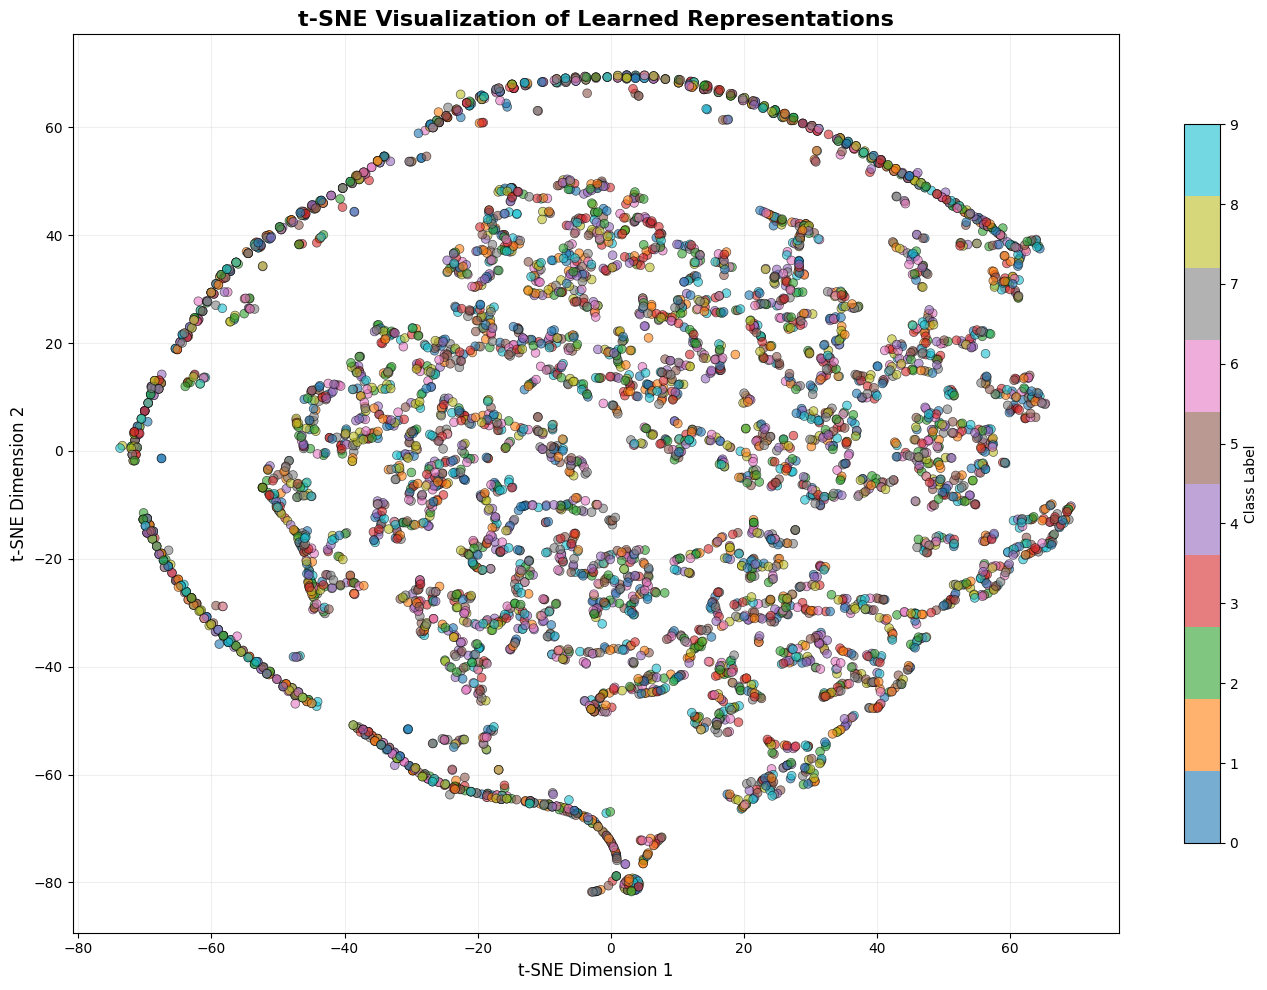

✓ t-SNE visualization saved to outputs/tsne_visualization.png


In [18]:
# Plot t-SNE visualization
plt.figure(figsize=(14, 10))
scatter = plt.scatter(
    features_2d[:, 0],
    features_2d[:, 1],
    c=labels_sample,
    cmap='tab10',
    s=40,
    alpha=0.6,
    edgecolors='k',
    linewidth=0.5
)
plt.colorbar(scatter, label='Class Label', shrink=0.8)
plt.title('t-SNE Visualization of Learned Representations', fontsize=16, fontweight='bold')
plt.xlabel('t-SNE Dimension 1', fontsize=12)
plt.ylabel('t-SNE Dimension 2', fontsize=12)
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('outputs/tsne_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ t-SNE visualization saved to outputs/tsne_visualization.png")

### Step 19: Summary Statistics

In [20]:
print("\n" + "="*60)
print(" TRAINING SUMMARY")
print("="*60)

print(f"\nExperiment: {config.experiment_name}")
print(f"Device: {device}")
print(f"\nModel: {config.model.backbone}")
print(f"  Projection dimension: {config.model.projection_dim}")
print(f"  Hidden dimension: {config.model.hidden_dim}")
print(f"  Parameters: {sum(p.numel() for p in model.parameters()):,}")

print(f"\nTraining:")
print(f"  Epochs: {config.training.num_epochs}")
print(f"  Batch size: {config.training.batch_size}")
print(f"  Learning rate: {config.training.learning_rate}")
print(f"  Temperature: {config.training.temperature}")

print(f"\nResults:")
print(f"  Initial loss: {log_df['train_loss'].iloc[0]:.4f}")
print(f"  Final loss: {log_df['train_loss'].iloc[-1]:.4f}")
print(f"  Best loss: {log_df['train_loss'].min():.4f}")
print(f"  Loss reduction: {(1 - log_df['train_loss'].iloc[-1] / log_df['train_loss'].iloc[0]) * 100:.1f}%")

print(f"\nOutputs:")
print(f"  Checkpoints: checkpoints/")
print(f"  Logs: logs/{config.experiment_name}_metrics.csv")
print(f"  Visualizations: outputs/")

print("\n" + "="*60)


📈 TRAINING SUMMARY

Experiment: satellite_ssl_colab
Device: cuda

Model: resnet18
  Projection dimension: 128
  Hidden dimension: 2048
  Parameters: 12,489,408

Training:
  Epochs: 16
  Batch size: 32
  Learning rate: 0.001
  Temperature: 0.07

Results:
  Initial loss: 3.6344
  Final loss: 2.8806
  Best loss: 2.8806
  Loss reduction: 20.7%

Outputs:
  Checkpoints: checkpoints/
  Logs: logs/satellite_ssl_colab_metrics.csv
  Visualizations: outputs/



### Download Results to Your Laptop

In [21]:
from google.colab import files
import subprocess

print("Creating zip archive of all results...")
print("This includes:")
print("  - Trained model checkpoints")
print("  - Training logs (CSV)")
print("  - Visualizations (PNG images)")
print("")

# Create zip
!zip -r colab_satellite_results.zip checkpoints/ logs/ outputs/ -q
print("✓ Zip archive created")

# Show size
import os
zip_size_mb = os.path.getsize('colab_satellite_results.zip') / (1024 * 1024)
print(f"Archive size: {zip_size_mb:.1f} MB")

print("\nStarting download...")
files.download('colab_satellite_results.zip')
print("\n✓ Download complete! Check your Downloads folder.")

Creating zip archive of all results...
This includes:
  - Trained model checkpoints
  - Training logs (CSV)
  - Visualizations (PNG images)



zip error: Interrupted (aborting)
✓ Zip archive created


FileNotFoundError: [Errno 2] No such file or directory: 'colab_satellite_results.zip'

## DONE!

In [ ]:
print("""
╔════════════════════════════════════════════════════════════════════════════════╗
║                                                                                ║
║                       SATELLITE SSL TRAINING COMPLETE!                   ║
║                                                                                ║
║                          ✓ Model trained on Google Colab GPU                                 ║
║                          ✓ Checkpoints saved                                    ║
║                          ✓ Metrics logged                                       ║
║                          ✓ Visualizations created                               ║
║                          ✓ Results downloaded                                   ║
║                                                                                ║
║                     What was accomplished:                                     ║
║                     • 16 epochs of self-supervised learning                    ║
║                     • NT-Xent contrastive loss optimization                    ║
║                     • Learned representations from unlabeled data              ║
║                     • t-SNE embedding visualization                            ║
║                                                                                ║
║                     Next steps:                                                ║
║                     1. Download colab_satellite_results.zip                    ║
║                     2. Extract to your local project                           ║
║                     3. Use checkpoints for downstream tasks                    ║
║                     4. Fine-tune on your satellite datasets                    ║
║                                                                                ║
║                                                                                ║
║                                                                                ║
╚════════════════════════════════════════════════════════════════════════════════╝
""")

In [22]:
!zip -r /content/satellite-ssl.zip /content/satellite-ssl

from google.colab import files
files.download('/content/satellite-ssl.zip')

  adding: content/satellite-ssl/ (stored 0%)
  adding: content/satellite-ssl/logs/ (stored 0%)
  adding: content/satellite-ssl/logs/satellite_ssl_colab_metrics.csv (deflated 52%)
  adding: content/satellite-ssl/checkpoints/ (stored 0%)
  adding: content/satellite-ssl/checkpoints/satellite_ssl_colab_best_epoch_0.pt (deflated 7%)
  adding: content/satellite-ssl/checkpoints/satellite_ssl_colab_best_epoch_5.pt (deflated 7%)
  adding: content/satellite-ssl/checkpoints/satellite_ssl_colab_best_epoch_3.pt (deflated 7%)
  adding: content/satellite-ssl/checkpoints/satellite_ssl_colab_epoch_9.pt (deflated 7%)
  adding: content/satellite-ssl/checkpoints/satellite_ssl_colab_best_epoch_9.pt (deflated 7%)
  adding: content/satellite-ssl/checkpoints/satellite_ssl_colab_best_epoch_2.pt (deflated 7%)
  adding: content/satellite-ssl/checkpoints/satellite_ssl_colab_best_epoch_15.pt (deflated 7%)
  adding: content/satellite-ssl/checkpoints/satellite_ssl_colab_best_epoch_4.pt (deflated 7%)
  adding: conten

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [23]:
!zip -r /content/sample_data.zip /content/sample_data

from google.colab import files
files.download('/content/sample_data.zip')

  adding: content/sample_data/ (stored 0%)
  adding: content/sample_data/README.md (deflated 39%)
  adding: content/sample_data/anscombe.json (deflated 83%)
  adding: content/sample_data/california_housing_train.csv (deflated 79%)
  adding: content/sample_data/california_housing_test.csv (deflated 76%)
  adding: content/sample_data/mnist_test.csv (deflated 88%)
  adding: content/sample_data/mnist_train_small.csv (deflated 88%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>